In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

In [2]:
data_path = 'p1_data.csv'
p1_df = pd.read_csv(data_path)

In [3]:
# determine velocites, thickness of the top layer, locate the vertical discontinuity
"""
======== V2
V1  |  V3
    |
"""

'\n======== V2\nV1  |  V3\n    |\n'

In [4]:
# use eq 3.21 pg 74
revers_dist = p1_df.dist_from_shot_m[::-1]
revers_dist

11    120
10    110
9     100
8      90
7      80
6      70
5      60
4      50
3      40
2      30
1      20
0      10
Name: dist_from_shot_m, dtype: int64

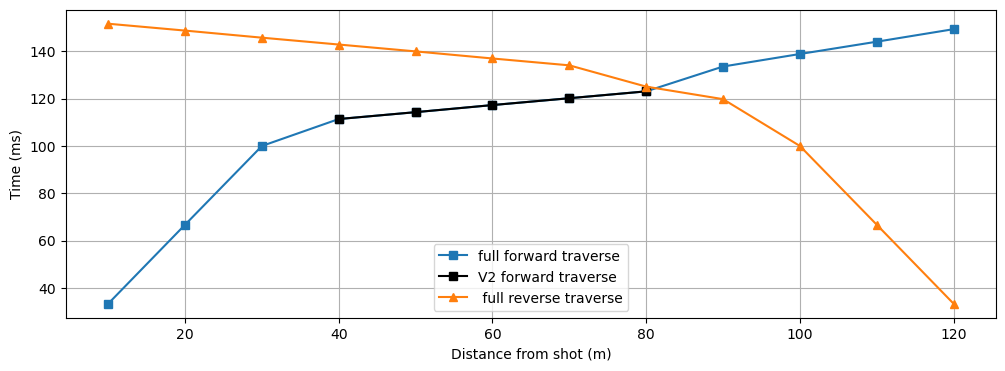

In [5]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(p1_df.dist_from_shot_m, p1_df.forward_traverse_ms, marker='s',label='full forward traverse')
ax.plot(p1_df.dist_from_shot_m[3:8], p1_df.forward_traverse_ms[3:8], marker='s',color='k',label='V2 forward traverse')
ax.plot(p1_df.dist_from_shot_m[::-1], p1_df.reverse_traverse_ms, marker='^',label=' full reverse traverse')
ax.set_xlabel('Distance from shot (m)')
ax.set_ylabel("Time (ms)")
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
# Forward velocities
v_2, t2_int = np.polyfit(p1_df.dist_from_shot_m[3:7], p1_df.forward_traverse_ms[3:7], 1)
# direct wave
v_1, t1_int = np.polyfit(p1_df.dist_from_shot_m[0:2], p1_df.forward_traverse_ms[0:2], 1)
# second layer
v_3, t3_int = np.polyfit(p1_df.dist_from_shot_m[8:11], p1_df.forward_traverse_ms[8:11], 1)


In [ ]:
print(f"velocity of layer 1: {v_2*1000:.2f} m/s. Time-axis intercet: {t1_int}.")
print(f"velocity of direct wave:{v_1*1000:.2f} m/s. Time intercept: {t2_int:.2f}.")
print(f"velocity of direct wave:{v_3*1000:.2f} m/s. Time intercept: {t3_int:.2f}.")

293.9999999999989 -0.10000000000000392
3339.9999999999995 99.63000000000007


In [23]:
# thickness h1
h1 = (t2_int / 2) * (v_2 * v_1) / np.sqrt(np.square(v_1) - np.square(v_2))
print(f"thickness of horizontal top layer: {h1:.2f} m")

thickness of horizontal top layer: 14.70 m
